# Installation of Dependencies

In [ ]:
!pip install effdet
!pip install pycocotools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 8.0 MB/s eta 0:00:00


# Import Libraries

In [ ]:
import torch
from torch.utils.data import Dataset
from effdet.data.parsers import create_parser
from pycocotools.coco import COCO
import cv2
import os

# Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Define Dataset Paths

In [ ]:

image_dir = '/content/drive/MyDrive/wfd_dataset/'
train_csv = '/content/drive/MyDrive/data_train.csv'
valid_csv = '/content/drive/MyDrive/data_valid.csv'
test_csv = '/content/drive/MyDrive/data_test.csv'

# Verify and Clean Image Data

In [ ]:

import pandas as pd
import os

def verify_images(csv_path, image_dir, filename_col='img'):
    df = pd.read_csv(csv_path)
    if filename_col not in df.columns:
        print(f"Available columns in {csv_path}: {df.columns.tolist()}")
        raise KeyError(f"No '{filename_col}' column in {csv_path}. Please check the CSV header and adjust the filename_col parameter.")
    missing = []
    for filename in df[filename_col]:
        img_path = os.path.join(image_dir, filename)
        if not os.path.exists(img_path):
            missing.append(filename)
    if missing:
        print(f"Warning: {len(missing)} missing images in {csv_path}: {missing}")
    else:
        print(f"All images in {csv_path} exist.")
    return df

# Load and verify (adjust filename_col if needed, e.g., to 'image' or 'file_name')
train_df = verify_images(train_csv, image_dir, filename_col='img')
valid_df = verify_images(valid_csv, image_dir, filename_col='img')
test_df = verify_images(test_csv, image_dir, filename_col='img')

# Optional: Save cleaned CSVs if you want to remove rows with missing images
train_df = train_df[train_df['img'].apply(lambda f: os.path.exists(os.path.join(image_dir, f)))]  # Note: Update 'filename' here if changed
valid_df = valid_df[valid_df['img'].apply(lambda f: os.path.exists(os.path.join(image_dir, f)))]
test_df = test_df[test_df['img'].apply(lambda f: os.path.exists(os.path.join(image_dir, f)))]

# Print sample to verify multi-label mapping
print("Sample from train_df:")
print(train_df.head(1))

print("Sample from train_df:")
print(train_df.head(1))

All images in /content/drive/MyDrive/data_train.csv exist.
All images in /content/drive/MyDrive/data_valid.csv exist.
All images in /content/drive/MyDrive/data_test.csv exist.
Sample from train_df:
                    img  healthy  leaf_rust  powdery_mildew  seedlings  \
0  0000000181ffff7e.jpg        0          1               0          1   

   septoria  stem_rust  yellow_rust  
0         0          0            0  
Sample from train_df:
                    img  healthy  leaf_rust  powdery_mildew  seedlings  \
0  0000000181ffff7e.jpg        0          1               0          1   

   septoria  stem_rust  yellow_rust  
0         0          0            0  


# Dataset and Augmentation Setup

In [ ]:
# Cell 5: Define Dataset class for mapping images to multi-labels
import torch
from torch.utils.data import Dataset
import cv2
from albumentations import Compose, Resize, Normalize, HorizontalFlip, RandomBrightnessContrast
from albumentations.pytorch import ToTensorV2

class WFD2020Dataset(Dataset):
    def __init__(self, df, image_dir, transforms=None):
        self.df = df
        self.image_dir = image_dir
        self.transforms = transforms
        self.labels = ['leaf_rust', 'stem_rust', 'yellow_rust', 'powdery_mildew', 'septoria', 'healthy', 'seedlings']

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row['img'])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        label = torch.tensor(row[self.labels].values.astype(float), dtype=torch.float32)

        if self.transforms:
            img = self.transforms(image=img)['image']

        return img, label


train_transforms = Compose([
    Resize(380, 380),
    HorizontalFlip(p=0.5),
    RandomBrightnessContrast(p=0.5),
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

eval_transforms = Compose([
    Resize(380, 380),
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])


train_dataset = WFD2020Dataset(train_df, image_dir, transforms=train_transforms)
valid_dataset = WFD2020Dataset(valid_df, image_dir, transforms=eval_transforms)
test_dataset = WFD2020Dataset(test_df, image_dir, transforms=eval_transforms)

print(f"Train samples: {len(train_dataset)}, Valid: {len(valid_dataset)}, Test: {len(test_dataset)}")

Train samples: 1454, Valid: 480, Test: 480


# Data Visualization Sample

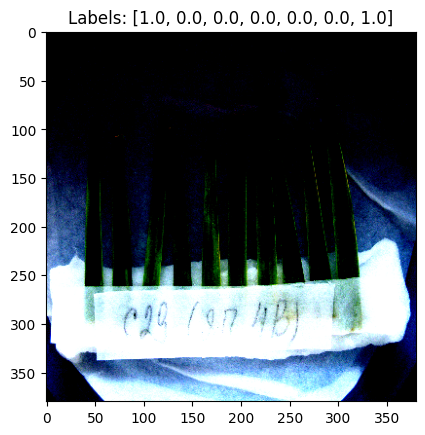

In [ ]:
# Cell 6: Optional - Test mapping with a sample (visualize an image and its labels)
import matplotlib.pyplot as plt


# Get a sample
img, label = train_dataset[0]  # First train sample
img_np = img.permute(1, 2, 0).numpy()  # CHW to HWC for plotting

plt.imshow(img_np)
plt.title(f"Labels: {label.tolist()}")
plt.show()

# Model Training and Validation

In [ ]:
# Cell 6: Train the model
import timm
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import AdamW
from sklearn.metrics import f1_score, precision_recall_curve, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt


# Model
model = timm.create_model('efficientnet_b4', pretrained=True, num_classes=7)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)  # Reduced workers for Colab
val_loader = DataLoader(valid_dataset, batch_size=16, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

# Loss and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = AdamW(model.parameters(), lr=1e-4)

# Track metrics
train_losses = []
val_losses = []
val_f1_scores = []

num_epochs = 20
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    print(f'Epoch {epoch+1}: Train Loss = {avg_train_loss}')

    # Validation
    model.eval()
    val_loss = 0
    val_preds, val_labels = [], []
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            preds = torch.sigmoid(outputs).cpu().numpy() > 0.5
            val_preds.extend(preds)
            val_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    f1 = f1_score(np.array(val_labels), np.array(val_preds), average='micro')
    val_f1_scores.append(f1)
    print(f'Epoch {epoch+1}: Val Loss = {avg_val_loss}, Val F1: {f1}')

# Save model to Drive
torch.save(model.state_dict(), '/content/drive/MyDrive/efficientnet_wfd2020_classification.pth')

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

Epoch 1: Train Loss = 0.4606445968806089
Epoch 1: Val Loss = 0.3788003265857697, Val F1: 0.43559718969555034
Epoch 2: Train Loss = 0.31404080806852697
Epoch 2: Val Loss = 0.31404619961977004, Val F1: 0.582995951417004
Epoch 3: Train Loss = 0.23751630380258457
Epoch 3: Val Loss = 0.2673654874165853, Val F1: 0.6616113744075829
Epoch 4: Train Loss = 0.17946717175808583
Epoch 4: Val Loss = 0.2409567711253961, Val F1: 0.7178538390379279
Epoch 5: Train Loss = 0.13669008900831034
Epoch 5: Val Loss = 0.22727703203757604, Val F1: 0.7316636851520573
Epoch 6: Train Loss = 0.09505605701725561
Epoch 6: Val Loss = 0.22244082540273666, Val F1: 0.7546174142480211
Epoch 7: Train Loss = 0.07252759439359
Epoch 7: Val Loss = 0.22958539053797722, Val F1: 0.7624784853700516
Epoch 8: Train Loss = 0.053476795728144406
Epoch 8: Val Loss = 0.2510983347892761, Val F1: 0.7624784853700516
Epoch 9: Train Loss = 0.041520085329046615
Epoch 9: Val Loss = 0.26834915230671563, Val F1: 0.7552921253175275
Epoch 10: Train 

# Performance Evaluation and Plotting

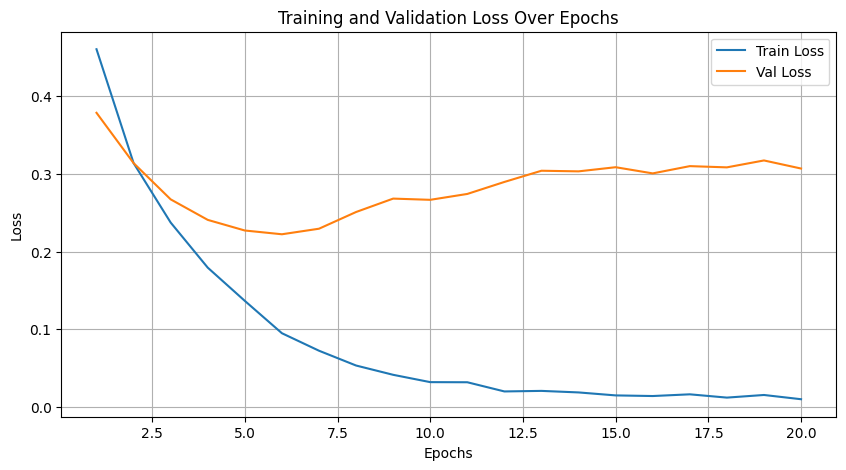

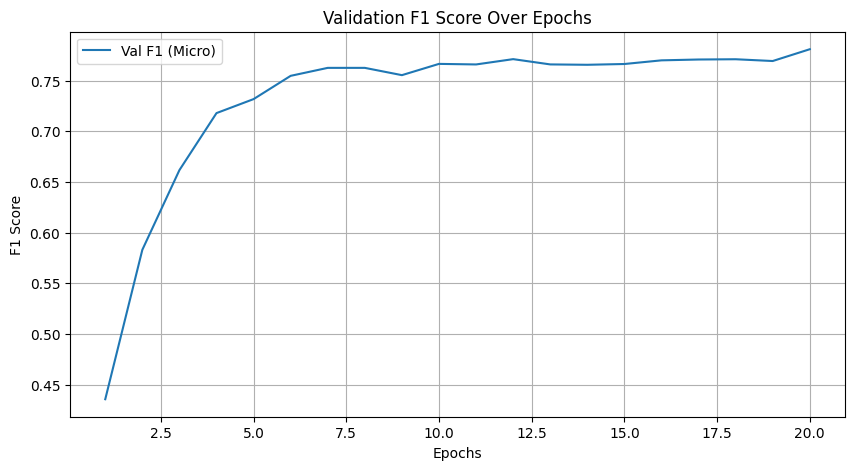

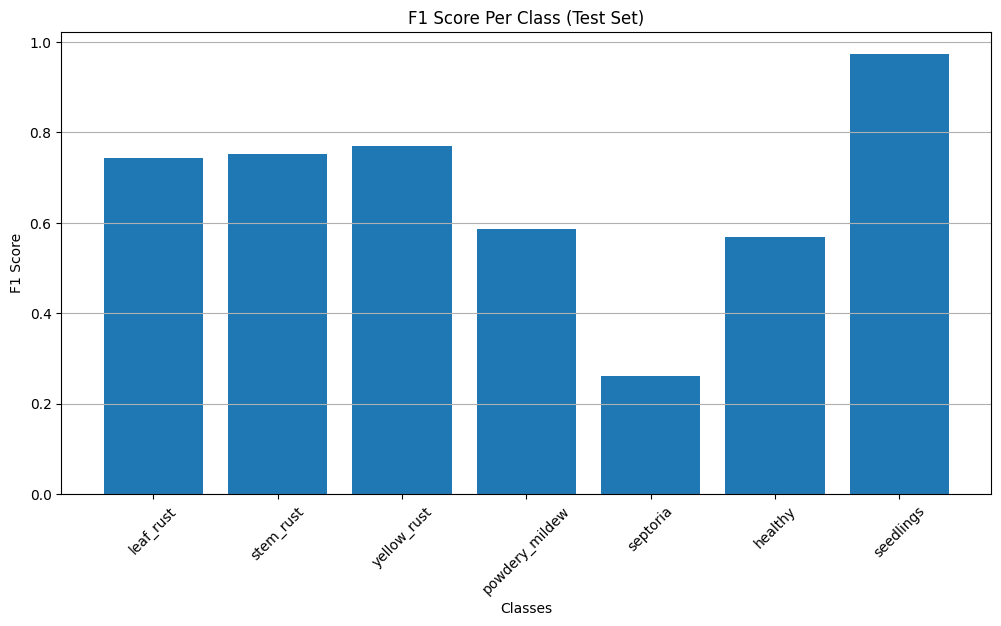

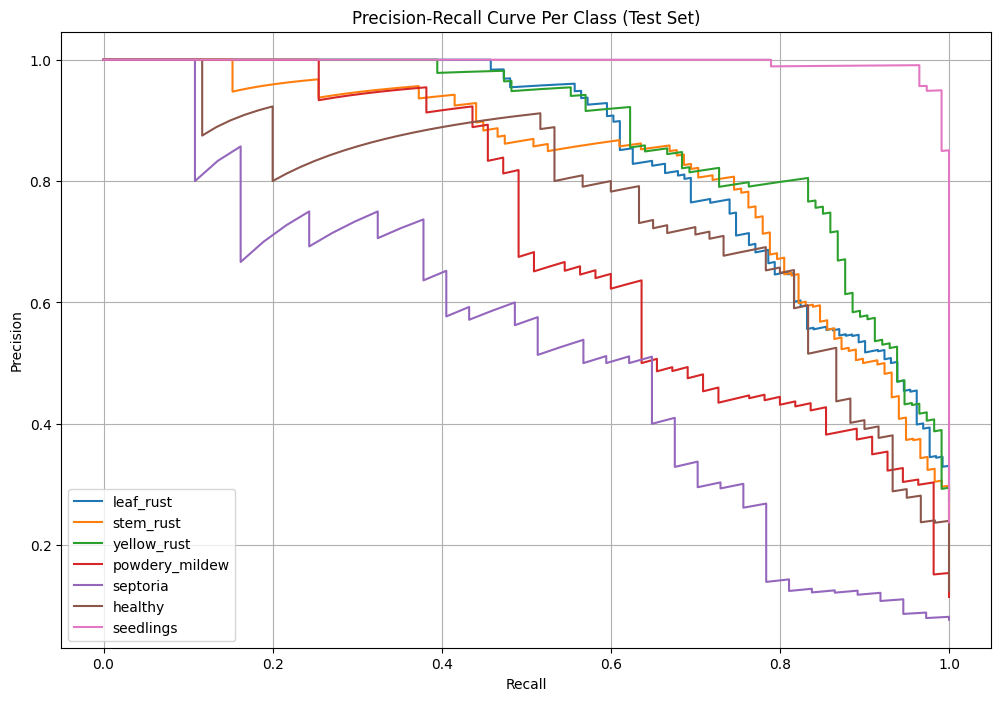

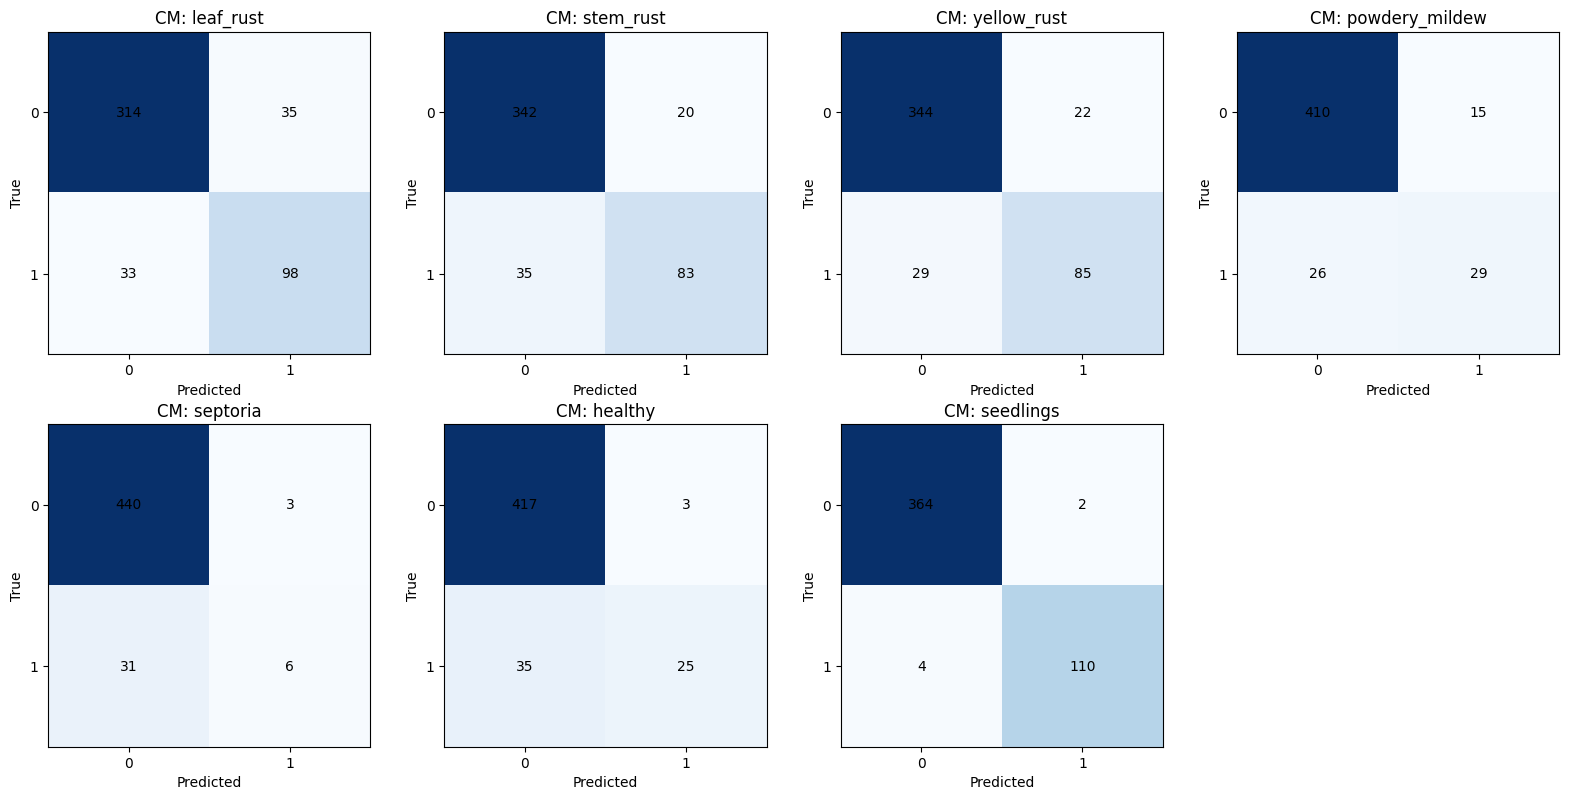

In [ ]:
# Cell 7: Generate and display performance plots
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score, precision_recall_curve, confusion_matrix

# Class names
labels_columns = ['leaf_rust', 'stem_rust', 'yellow_rust', 'powdery_mildew', 'septoria', 'healthy', 'seedlings']

# Loss curves
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.savefig('/content/drive/MyDrive/loss_curve_efficientNet.png')
plt.show()

# F1 over epochs
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), val_f1_scores, label='Val F1 (Micro)')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.title('Validation F1 Score Over Epochs')
plt.legend()
plt.grid(True)
plt.savefig('/content/drive/MyDrive/f1_curve.png')
plt.show()

# Test set evaluation
model.eval()
test_preds, test_labels = [], []
test_probs = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).cpu().numpy()
        preds = probs > 0.5
        test_preds.extend(preds)
        test_labels.extend(labels.cpu().numpy())
        test_probs.extend(probs)

test_preds = np.array(test_preds)
test_labels = np.array(test_labels)
test_probs = np.array(test_probs)

# F1 per class bar plot
f1_per_class = f1_score(test_labels, test_preds, average=None)
plt.figure(figsize=(12, 6))
plt.bar(labels_columns, f1_per_class)
plt.xlabel('Classes')
plt.ylabel('F1 Score')
plt.title('F1 Score Per Class (Test Set)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.savefig('/content/drive/MyDrive/f1_per_class.png')
plt.show()

# Precision-Recall Curve per class
plt.figure(figsize=(12, 8))
for i, label_name in enumerate(labels_columns):
    precision, recall, _ = precision_recall_curve(test_labels[:, i], test_probs[:, i])
    plt.plot(recall, precision, label=label_name)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Per Class (Test Set)')
plt.legend()
plt.grid(True)
plt.savefig('/content/drive/MyDrive/pr_curves_EfficientNet.png')
plt.show()

# Confusion Matrix per class
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, label_name in enumerate(labels_columns):
    cm = confusion_matrix(test_labels[:, i], test_preds[:, i])
    axes[i].imshow(cm, interpolation='nearest', cmap='Blues')
    axes[i].set_title(f'CM: {label_name}')
    axes[i].set_xticks([0, 1])
    axes[i].set_yticks([0, 1])
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')
    for x in range(2):
        for y in range(2):
            axes[i].text(y, x, cm[x, y], ha='center', va='center', color='black')

if len(labels_columns) < len(axes):
    for j in range(len(labels_columns), len(axes)):
        axes[j].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrices_EfficientNet.png')
plt.show()

# Export Predictions to CSV

In [ ]:
import pandas as pd

# Prepare the data for the CSV
# Note: test_labels and test_preds are lists of arrays from the previous cell execution
prediction_data = []
labels_columns = ['leaf_rust', 'stem_rust', 'yellow_rust', 'powdery_mildew', 'septoria', 'healthy', 'seedlings']

for i in range(len(test_df)):
    filename = test_df.iloc[i]['img']
    # Get boolean predictions for this index and convert to int (0/1)
    preds_row = test_preds[i].astype(int).tolist()

    entry = {'img': filename}
    for idx, col_name in enumerate(labels_columns):
        entry[f'pred_{col_name}'] = preds_row[idx]
    prediction_data.append(entry)

# Create DataFrame and save to CSV
results_df = pd.DataFrame(prediction_data)
csv_filename = 'test_predictions.csv'
results_df.to_csv(csv_filename, index=False)

print(f'Predictions saved to {csv_filename}')
display(results_df.head())

Predictions saved to test_predictions.csv


,img,pred_leaf_rust,pred_stem_rust,pred_yellow_rust,pred_powdery_mildew,pred_septoria,pred_healthy,pred_seedlings
0,0000000001ffffff.jpg,1,0,0,0,0,0,1
1,00000000ffffffff.jpg,1,0,0,0,0,0,1
2,00000003c3ff7f3e.jpg,1,0,0,0,0,0,1
3,00000010ffffffff.jpg,1,0,0,0,0,0,1
4,0000001efffffffc.jpg,0,0,0,0,0,1,1
